# 1. Machine Learning System (Traditional ML)

Dataset Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MedInc            20640 non-null  float64
 1   HouseAge          20640 non-null  float64
 2   AveRooms          20640 non-null  float64
 3   AveBedrms         20640 non-null  float64
 4   Population        20640 non-null  float64
 5   AveOccup          20640 non-null  float64
 6   Latitude          20640 non-null  float64
 7   Longitude         20640 non-null  float64
 8   MedianHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   113

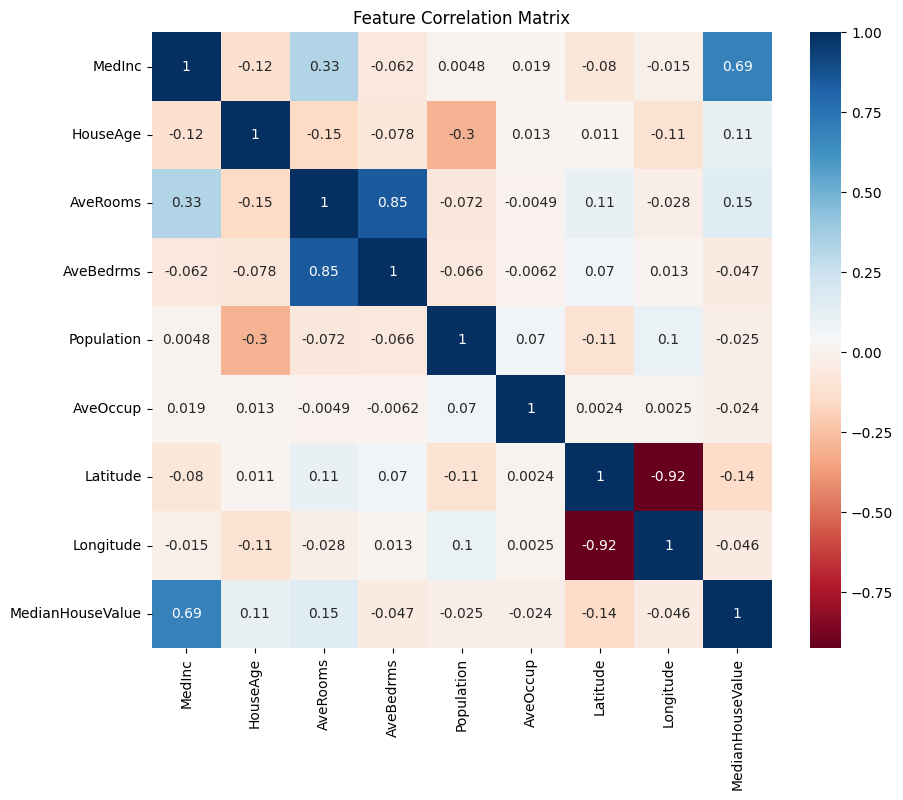


--- Linear Regression ---
R2 Score: 0.5758
MAE: 0.5332
RMSE: 0.7456

--- Decision Tree ---
R2 Score: 0.6230
MAE: 0.4539
RMSE: 0.7028

--- Random Forest ---
R2 Score: 0.8053
MAE: 0.3274
RMSE: 0.5051


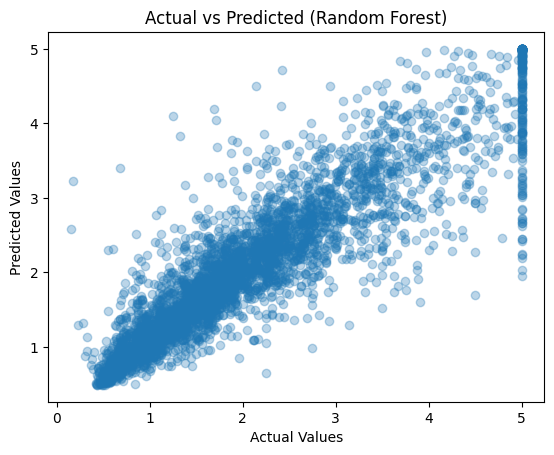

['house_price_model.pkl']

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 8. Fetch the California Housing dataset directly from Scikit-learn [cite: 76, 77, 99]
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedianHouseValue'] = data.target

# 9. Initial data inspection [cite: 78, 104]
print(f"Dataset Shape: {df.shape}")
print(df.info())
print(df.describe())

# 11. Exploratory Data Analysis (EDA) - Correlation Matrix [cite: 80]
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdBu')
plt.title("Feature Correlation Matrix")
plt.show()

# 13. Split the dataset (80:20) [cite: 81]
X = df.drop('MedianHouseValue', axis=1)
y = df['MedianHouseValue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 15. Feature Scaling [cite: 83, 105]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 14 & 16. Implement Models (Linear Regression, Decision Tree, Random Forest) [cite: 82, 84]
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    
    # 17. Evaluate performance [cite: 85, 112]
    print(f"\n--- {name} ---")
    print(f"R2 Score: {r2_score(y_test, predictions):.4f}")
    print(f"MAE: {mean_absolute_error(y_test, predictions):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions)):.4f}")

# 18. Visualize performance (Actual vs Predicted) [cite: 86]
plt.scatter(y_test, models["Random Forest"].predict(X_test_scaled), alpha=0.3)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

# 21. Save and export the final trained model [cite: 89]
joblib.dump(models["Random Forest"], 'house_price_model.pkl')

# 2. Deep Learning System (Neural Networks)

I0000 00:00:1776440974.726111    2296 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776440982.467375    2296 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1753 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/100


I0000 00:00:1776440987.168979    2521 service.cc:153] XLA service 0x74507c032420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776440987.169057    2521 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.17.1)
I0000 00:00:1776440987.249491    2521 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776440987.602318    2521 cuda_dnn.cc:461] Loaded cuDNN version 91701
I0000 00:00:1776440987.694738    2521 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1342__.10


 24/452 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.9769 - mae: 1.8737

I0000 00:00:1776440991.411067    2521 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


450/452 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1109 - mae: 1.0043

I0000 00:00:1776440994.615896    2520 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1342__.10


452/452 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 1.1702 - mae: 0.7276 - val_loss: 0.4746 - val_mae: 0.4928
Epoch 2/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.5073 - mae: 0.5082 - val_loss: 0.3988 - val_mae: 0.4430
Epoch 3/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4725 - mae: 0.4768 - val_loss: 0.3788 - val_mae: 0.4414
Epoch 4/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4345 - mae: 0.4666 - val_loss: 0.3803 - val_mae: 0.4334
Epoch 5/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.4147 - mae: 0.4583 - val_loss: 0.3632 - val_mae: 0.4238
Epoch 6/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.4021 - mae: 0.4489 - val_loss: 0.3523 - val_mae: 0.4191
Epoch 7/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3907 - mae: 0.4426 - val_loss: 0.3426 - val_mae: 0.4128
Epoch 8/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3877 - mae: 0.4387 - val_loss: 0.3462 - val_mae: 0.4210
Epoch 9/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - los

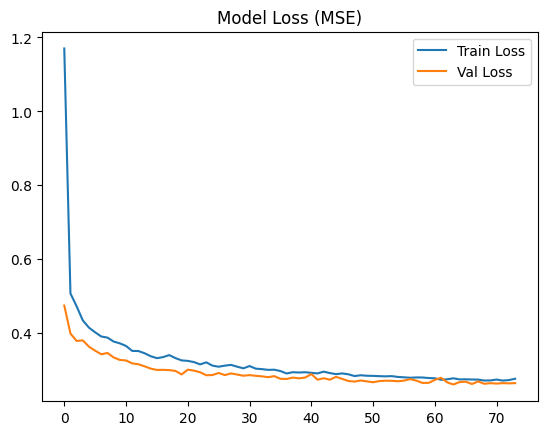

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# 12. Split into Training, Validation, and Testing sets (70:15:15) [cite: 107]
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.176, random_state=42) # 0.176 of 85% is ~15%

# Re-scale data for Deep Learning [cite: 105]
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 13 & 14. Design DNN Architecture [cite: 108, 109]
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.2), # 19. Regularization [cite: 114]
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear') # Output layer for regression [cite: 109]
])

# 15. Compile the model [cite: 110]
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 16. Train the model with Early Stopping [cite: 111, 114]
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 18. Visualize training vs validation loss [cite: 113]
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (MSE)')
plt.legend()
plt.show()

# 21. Save and export the trained neural network [cite: 116]
model.save('house_price_dnn_model.h5')